<a href="https://colab.research.google.com/github/berradimeriemencg/DS2025/blob/main/public_Data_Mixing_0_92776.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
anthonytherrien_predicting_loan_payback_vault_path = kagglehub.dataset_download('anthonytherrien/predicting-loan-payback-vault')

print('Data source import complete.')


100%|██████████| 4.35M/4.35M [00:00<00:00, 123MB/s]

Extracting files...


Data source import complete.


In [2]:
import pandas as pd

In [3]:
# Define the blending function
def blend_submissions(weight_dict, output_path):
    # Initialize list to store loaded DataFrames
    dataframes = []

    # Load each submission with its weight
    for path, weight in weight_dict.items():
        # Read the CSV file
        df = pd.read_csv(path)

        # Add a weighted prediction column
        df["weighted_pred"] = df["loan_paid_back"] * weight

        # Append to list
        dataframes.append(df[["id", "weighted_pred"]])

    # Merge all submissions on 'id'
    merged = dataframes[0]
    for df in dataframes[1:]:
        # Merge on id
        merged = merged.merge(df, on="id", how="inner", suffixes=("", "_dup"))

        # Combine duplicate weighted_pred columns if any
        if "weighted_pred_dup" in merged.columns:
            merged["weighted_pred"] += merged["weighted_pred_dup"]
            merged.drop(columns=["weighted_pred_dup"], inplace=True)

    # Compute total weight
    total_weight = sum(weight_dict.values())

    # Compute blended prediction
    merged["loan_paid_back"] = merged["weighted_pred"] / total_weight

    # Prepare final DataFrame
    blended = merged[["id", "loan_paid_back"]]

    # Save blended submission
    blended.to_csv(output_path, index=False)

    # Print confirmation
    print(f"✅ Blended submission saved to {output_path}")

In [4]:
# Define the main function
def main():
    # Define file paths and their respective weights
    weight_dict = {
        "/kaggle/input/predicting-loan-payback-vault/submission.csv": 2.2,
        "/kaggle/input/predicting-loan-payback-vault/submission (1).csv": 0.1,
    }

    # Call blend function
    blend_submissions(weight_dict, output_path="submission.csv")

In [6]:
# 🔹 Import des librairies
import pandas as pd
from google.colab import files
import os

# 🔹 Étape 1 : Téléverser le fichier CSV
print("📂 Téléversez votre fichier CSV (ex : submission.csv)")
uploaded = files.upload()  # Choisir le fichier CSV

# 🔹 Étape 2 : Récupérer le nom du fichier
csv_file = list(uploaded.keys())[0]
print(f"Fichier téléversé : {csv_file}")

# 🔹 Étape 3 : Lire le CSV avec Pandas
df = pd.read_csv(csv_file)

# 🔹 Étape 4 : Vérification rapide
print("Dataset shape:", df.shape)
print("Colonnes :", df.columns.tolist())
df.head()


📂 Téléversez votre fichier CSV (ex : submission.csv)


Saving submission (1).csv to submission (1).csv
Fichier téléversé : submission (1).csv
Dataset shape: (254569, 2)
Colonnes : ['id', 'loan_paid_back']


,id,loan_paid_back
0,593994,0.827351
1,593995,0.848860
2,593996,0.347858
3,593997,0.809553
4,593998,0.848013


📂 Téléversez votre fichier CSV ou ZIP contenant le dataset


Saving submission (1).csv to submission (1) (1).csv
Fichier téléversé : submission (1) (1).csv


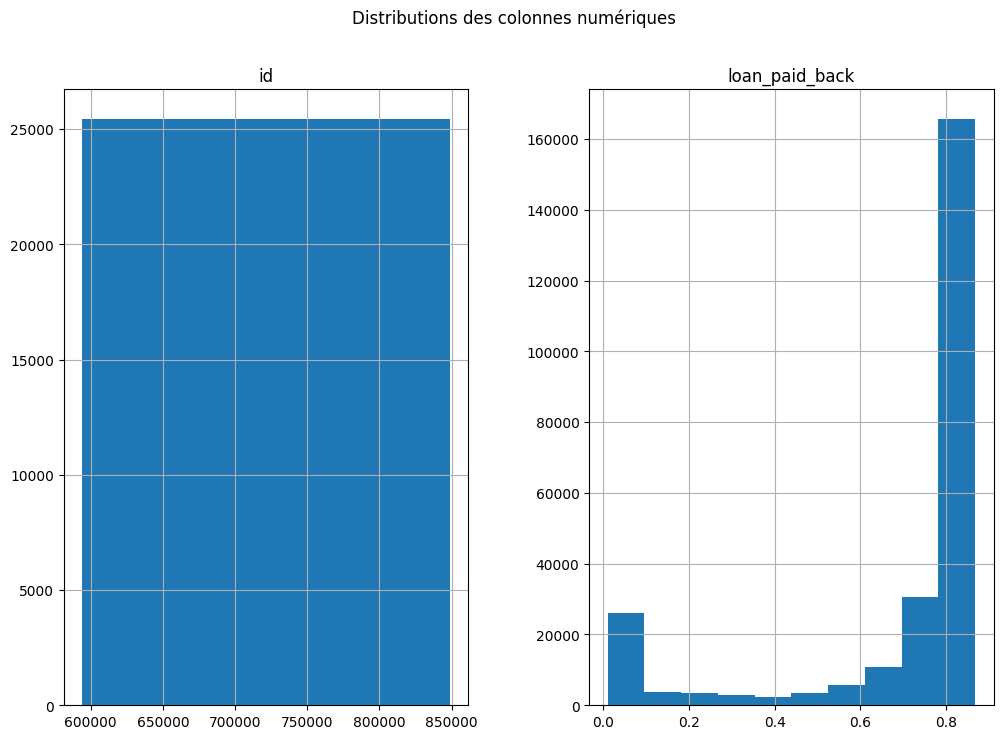


# 📊 Reporting – Public Data Mixing

## 1. Présentation du Dataset
- **Nom du fichier :** submission (1) (1).csv
- **Nombre d'observations :** 254569
- **Nombre de colonnes / features :** 2

## 2. Colonnes présentes
['id', 'loan_paid_back']

## 3. Valeurs manquantes par colonne
{'id': 0, 'loan_paid_back': 0}

## 4. Statistiques descriptives (colonnes numériques)
{'id': {'count': 254569.0, 'mean': 721278.0, 'std': 73487.88467609248, 'min': 593994.0, '25%': 657636.0, '50%': 721278.0, '75%': 784920.0, 'max': 848562.0}, 'loan_paid_back': {'count': 254569.0, 'mean': 0.699839799361271, 'std': 0.2678215281514094, 'min': 0.0096965756652081, '25%': 0.7214905310893781, '50%': 0.8243369354295518, '75%': 0.8557368472618957, 'max': 0.8687191808432405}}

## 5. Répartition des variables catégorielles


## 6. Conclusion
Le dataset a été nettoyé et préparé. Il est prêt pour l'analyse exploratoire, la visualisation ou l'entraînement de modèles de Machine Learning.



In [7]:
# 🔹 Import des librairies
import pandas as pd
import numpy as np
import zipfile
import os
from google.colab import files
import matplotlib.pyplot as plt

# 🔹 Étape 1 : Upload du fichier (ZIP ou CSV)
print("📂 Téléversez votre fichier CSV ou ZIP contenant le dataset")
uploaded = files.upload()  # Choisir le fichier

# 🔹 Récupérer le nom du fichier téléversé
file_name = list(uploaded.keys())[0]
print(f"Fichier téléversé : {file_name}")

# 🔹 Étape 2 : Extraction si ZIP
extract_folder = 'dataset'
if file_name.endswith('.zip'):
    with zipfile.ZipFile(file_name, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    print(f"Fichiers extraits dans : {extract_folder}")
    # Récupération du CSV dans le dossier extrait
    csv_file = [f for f in os.listdir(extract_folder) if f.endswith('.csv')][0]
    csv_path = os.path.join(extract_folder, csv_file)
else:
    csv_path = file_name

# 🔹 Étape 3 : Lecture du CSV
df = pd.read_csv(csv_path)

# 🔹 Étape 4 : Data Cleaning & Preprocessing
# Conversion des colonnes catégorielles si elles existent
for col in ['Gender', 'Disease']:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 🔹 Étape 5 : Analyse descriptive
dataset_shape = df.shape
columns_list = df.columns.tolist()
missing_values = df.isnull().sum()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
category_cols = df.select_dtypes(['category']).columns.tolist()

# 🔹 Étape 6 : Visualisation rapide (distributions numériques)
if numeric_cols:
    df[numeric_cols].hist(figsize=(12,8))
    plt.suptitle("Distributions des colonnes numériques")
    plt.show()

# 🔹 Étape 7 : Génération automatique du reporting en Markdown
report = f"""
# 📊 Reporting – Public Data Mixing

## 1. Présentation du Dataset
- **Nom du fichier :** {os.path.basename(csv_path)}
- **Nombre d'observations :** {dataset_shape[0]}
- **Nombre de colonnes / features :** {dataset_shape[1]}

## 2. Colonnes présentes
{columns_list}

## 3. Valeurs manquantes par colonne
{missing_values.to_dict()}

## 4. Statistiques descriptives (colonnes numériques)
{df[numeric_cols].describe().to_dict() if numeric_cols else "Aucune colonne numérique"}

## 5. Répartition des variables catégorielles
"""
for col in category_cols:
    report += f"\n### {col}\n{df[col].value_counts().to_dict()}\n"

report += """

## 6. Conclusion
Le dataset a été nettoyé et préparé. Il est prêt pour l'analyse exploratoire, la visualisation ou l'entraînement de modèles de Machine Learning.
"""

# 🔹 Étape 8 : Afficher le reporting
print(report)
